In [40]:
df_clean.to_csv("ab_testing_clean.csv", index=False)

print("Clean dataset exported successfully!")

Clean dataset exported successfully!


In [39]:
print("========== A/B TEST SUMMARY ==========")

print(f"Control CTR: {control_rate * 100:.2f}%")
print(f"Experimental CTR: {experimental_rate * 100:.2f}%")
print(f"CTR Uplift: {ctr_uplift:.2f}%")
print(f"CTR p-value: < 0.001")

print()

print(f"Control Avg Session Time: {control_time.mean():.2f}")
print(f"Experimental Avg Session Time: {experimental_time.mean():.2f}")
print(f"Session Time p-value: {p_value_time:.4f}")

========== A/B TEST SUMMARY ==========
Control CTR: 20.01%
Experimental CTR: 49.75%
CTR Uplift: 148.59%
CTR p-value: < 0.001

Control Avg Session Time: 13.28
Experimental Avg Session Time: 12.71
Session Time p-value: 0.1166


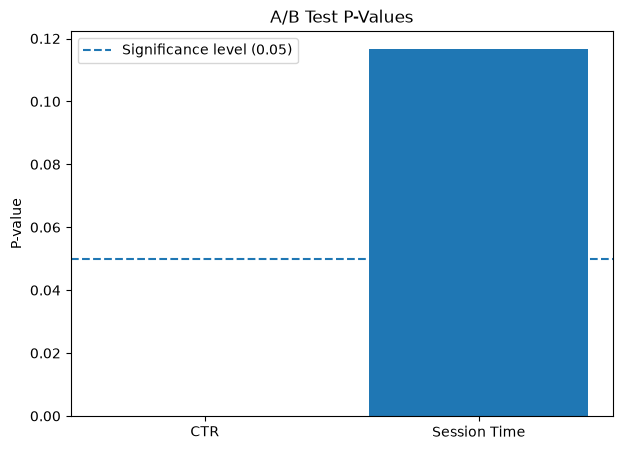

In [38]:
metrics = ["CTR", "Session Time"]
p_values = [p_value_ctr, p_value_time]

plt.figure(figsize=(7, 5))
plt.bar(metrics, p_values)

plt.axhline(
    y=0.05,
    linestyle="--",
    label="Significance level (0.05)"
)

plt.title("A/B Test P-Values")
plt.ylabel("P-value")

plt.legend()
plt.show()

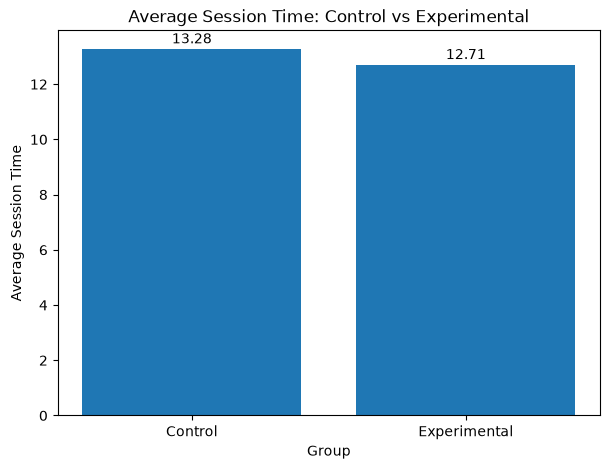

In [37]:
session_values = [
    control_time.mean(),
    experimental_time.mean()
]

plt.figure(figsize=(7, 5))
plt.bar(groups, session_values)

plt.title("Average Session Time: Control vs Experimental")
plt.xlabel("Group")
plt.ylabel("Average Session Time")

for i, value in enumerate(session_values):
    plt.text(i, value + 0.2, f"{value:.2f}", ha="center")

plt.show()

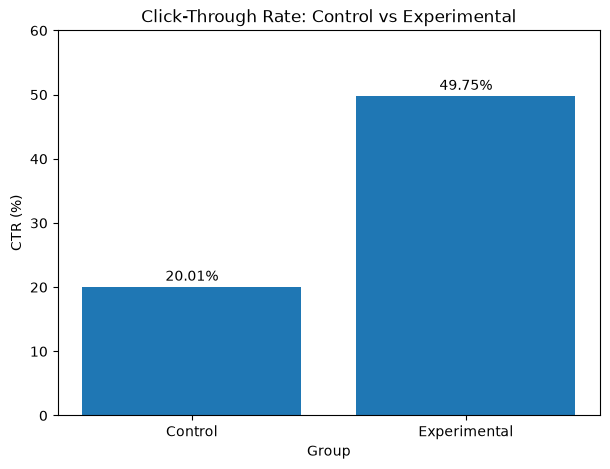

In [36]:
import matplotlib.pyplot as plt

groups = ["Control", "Experimental"]
ctr_values = [control_rate * 100, experimental_rate * 100]

plt.figure(figsize=(7, 5))
plt.bar(groups, ctr_values)

plt.title("Click-Through Rate: Control vs Experimental")
plt.xlabel("Group")
plt.ylabel("CTR (%)")

for i, value in enumerate(ctr_values):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.ylim(0, 60)
plt.show()

In [35]:
print("===== CTR A/B TEST RESULT =====")
print(f"Control CTR: {control_rate * 100:.2f}%")
print(f"Experimental CTR: {experimental_rate * 100:.2f}%")
print(f"CTR Uplift: {ctr_uplift:.2f}%")
print(f"CTR Difference: {difference * 100:.2f} percentage points")
print(f"95% CI: [{ci_lower * 100:.2f}%, {ci_upper * 100:.2f}%]")
print(f"p-value: < 0.001")

===== CTR A/B TEST RESULT =====
Control CTR: 20.01%
Experimental CTR: 49.75%
CTR Uplift: 148.59%
CTR Difference: 29.74 percentage points
95% CI: [29.33%, 30.14%]
p-value: < 0.001


In [34]:
# Difference in CTR
difference = experimental_rate - control_rate

# Standard error for confidence interval
se_diff = np.sqrt(
    (control_rate * (1 - control_rate) / control_n) +
    (experimental_rate * (1 - experimental_rate) / experimental_n)
)

# 95% Confidence Interval
ci_lower = difference - 1.96 * se_diff
ci_upper = difference + 1.96 * se_diff

print("CTR Difference:",
      round(difference * 100, 2), "percentage points")

print("95% CI Lower:",
      round(ci_lower * 100, 2), "%")

print("95% CI Upper:",
      round(ci_upper * 100, 2), "%")

CTR Difference: 29.74 percentage points
95% CI Lower: 29.33 %
95% CI Upper: 30.14 %


In [33]:
ctr_uplift = (
    (experimental_rate - control_rate)
    / control_rate
) * 100

print("CTR Uplift:", round(ctr_uplift, 2), "%")

CTR Uplift: 148.59 %


In [32]:
if p_value_time < 0.05:
    print("Result: Session time difference is statistically significant.")
else:
    print("Result: Session time difference is NOT statistically significant.")

Result: Session time difference is NOT statistically significant.


In [31]:
control_time = df_clean.loc[
    df_clean["group"] == "Control", "session_time"
]

experimental_time = df_clean.loc[
    df_clean["group"] == "Experimental", "session_time"
]

t_stat, p_value_time = stats.ttest_ind(
    control_time,
    experimental_time,
    equal_var=False
)

print("Control average session time:",
      round(control_time.mean(), 2))

print("Experimental average session time:",
      round(experimental_time.mean(), 2))

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value_time)

Control average session time: 13.28
Experimental average session time: 12.71
T-statistic: 1.5693
P-value: 0.11657820767940402


In [30]:
print(df.shape)
print(df.columns)

(200020, 6)
Index(['click', 'group', 'session_time', 'click_time', 'device_type',
       'referral_source'],
      dtype='str')


In [29]:
alpha = 0.05

if p_value_ctr < alpha:
    print("Result: Statistically significant difference in click rate.")
else:
    print("Result: No statistically significant difference in click rate.")

Result: Statistically significant difference in click rate.


In [28]:
# Click counts
control_clicks = df_clean.loc[
    df_clean["group"] == "Control", "click"
].sum()

experimental_clicks = df_clean.loc[
    df_clean["group"] == "Experimental", "click"
].sum()

# Sample sizes
control_n = (df_clean["group"] == "Control").sum()
experimental_n = (df_clean["group"] == "Experimental").sum()

# Click rates
control_rate = control_clicks / control_n
experimental_rate = experimental_clicks / experimental_n

# Pooled click rate
pooled_rate = (
    control_clicks + experimental_clicks
) / (control_n + experimental_n)

# Standard error
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate) *
    (1 / control_n + 1 / experimental_n)
)

# Z statistic
z_stat = (
    experimental_rate - control_rate
) / standard_error

# Two-tailed p-value
p_value_ctr = 2 * stats.norm.sf(abs(z_stat))

print("Control CTR:", round(control_rate * 100, 2), "%")
print("Experimental CTR:", round(experimental_rate * 100, 2), "%")
print("Z-statistic:", round(z_stat, 4))
print("P-value:", p_value_ctr)

Control CTR: 20.01 %
Experimental CTR: 49.75 %
Z-statistic: 137.4283
P-value: 0.0


In [27]:
df_clean.groupby("group").agg(
    users=("click", "count"),
    clicks=("click", "sum"),
    click_rate=("click", "mean"),
    avg_session_time=("session_time", "mean"),
    median_session_time=("session_time", "median")
)

,users,clicks,click_rate,avg_session_time,median_session_time
group,,,,,
Control,97002,19413,0.200130,13.280193,3.525665
Experimental,97052,48284,0.497506,12.710937,3.522216


In [26]:
df_clean.isnull().sum()

click                 0
group                 0
session_time          0
click_time         1935
device_type           0
referral_source     966
dtype: int64

In [25]:
# Keep only valid A/B test groups
df_clean = df[df["group"].isin(["con", "exp"])].copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Rename groups for clarity
df_clean["group"] = df_clean["group"].replace({
    "con": "Control",
    "exp": "Experimental"
})

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))

print("\nGroups after cleaning:")
print(df_clean["group"].value_counts())

Original rows: 200020
Clean rows: 194054

Groups after cleaning:
group
Experimental    97052
Control         97002
Name: count, dtype: int64


In [24]:
df["session_time"].describe()

count    200020.000000
mean         13.019501
std          80.026080
min           0.000007
25%           1.460555
50%           3.521112
75%           7.091051
max         807.785808
Name: session_time, dtype: float64

In [23]:
df["click"].value_counts()

click
0    130242
1     69778
Name: count, dtype: int64

In [22]:
df["group"].value_counts()

group
exp     97065
con     97020
con      1000
Exp       995
A         992
a         978
Name: count, dtype: int64

In [21]:
df.duplicated().sum()

np.int64(31)

In [20]:
df.isnull().sum()

click                 0
group              1970
session_time          0
click_time         2001
device_type           0
referral_source     989
dtype: int64

In [19]:
df.columns

Index(['click', 'group', 'session_time', 'click_time', 'device_type',
       'referral_source'],
      dtype='str')

In [18]:
df.shape

(200020, 6)

In [17]:
df = pd.read_csv("ab_test_dataset.csv")

df.head()

,click,group,session_time,click_time,device_type,referral_source
0,1,exp,0.040363,NaN,mobile,search
1,0,exp,1.639570,2024-01-14 22:15:00,mobile,email
2,0,exp,2.961715,2024-01-01 15:36:00,mobile,direct
3,1,exp,2.784540,2024-01-04 17:39:00,desktop,email
4,0,exp,2.495874,2024-01-07 17:31:00,mobile,social


In [16]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

print("Setup ready!")

Setup ready!


A/B Testing Analysis
Campaign Engagement — Control vs Experimental
Python • SciPy • Tableau